# CIFAR-100 Transfer Learning — MobileNetV3Small (fine / 100-way fine-class)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Fgram-devAI/deepl-cifar100-image-analysis/blob/main/notebooks/07_mobilenetv3_fine_frozen_unfrozen.ipynb)

A transfer-learning classifier for the fine label set of CIFAR-100: 100 fine classes, built on MobileNetV3Small pretrained on ImageNet. We train and evaluate two stages in sequence:

1. Frozen: the backbone is frozen and only a new softmax head is trained. This gives the frozen-feature-extractor result.
2. Unfrozen: the top of the backbone is unfrozen and fine-tuned at a much smaller learning rate, with BatchNorm kept frozen. This continues from the frozen stage and gives the fine-tuning result.

Each stage writes a full metric suite to Google Drive, producing two complete result sets (`fine_frozen_*` and `fine_unfrozen_*`). A companion notebook runs the same procedure on the coarse label set (20 superclasses), so the two notebooks together produce all four result sets.

The notebook is meant to run top to bottom on a GPU runtime (Runtime → Change runtime type → T4 GPU). `LEVEL` is fixed to `"fine"` in the configuration cell, so there is nothing to toggle.

## Where this sits in the pipeline

`data → preprocessing → model → training → evaluation`. This notebook is concentrated in the model, training, and evaluation stages, with a thin data layer feeding them. Two design choices are worth stating up front.

Preprocessing is split across two places. The `tf.data` layer does the cheap, stream-friendly part: decode, scale to `[0,1]`, and batch. The costly part, upscaling each image from 32×32 to 224×224 and rescaling it back to `[0,255]` for the backbone, runs inside the model as its first layers. That keeps it on the GPU and lets the input pipeline move only small 32×32 tensors. The `Rescaling(255.0)` step that reverses the `[0,1]` scaling is deliberate: it lets this model accept the same `[0,1]` pipeline the rest of the project uses.

The two stages share weights. Fine-tuning in the unfrozen stage modifies the same weights the frozen stage produced, so we run the full metric suite immediately after the frozen stage to record that baseline and checkpoint the frozen model before any fine-tuning happens. Once fine-tuning starts, the frozen baseline can only be recovered from that saved checkpoint and result set.

The 100 classes are balanced, with 500 training and 100 test images each, so accuracy is a meaningful headline metric. We use a plain softmax head with `SparseCategoricalCrossentropy`, no class weighting and no threshold tuning. We still report macro precision/recall, balanced accuracy, and Cohen's κ so each case has more than a single number behind it.

## 1 · Install `datasets` and confirm the GPU

TensorFlow is preinstalled on Colab. The Hugging Face `datasets` library is frequently out of date there, so we upgrade it. The GPU listing is the hardware check: an empty list means the session is running on CPU, where training is impractically slow.

In [1]:
# Cell 1 — install Hugging Face datasets, then confirm TF sees the T4 GPU
%pip install -q -U datasets
import tensorflow as tf
print("TF:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
# Empty GPU list? Runtime > Change runtime type > T4 GPU, then re-run this cell.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 20.9 MB/s eta 0:00:00
TF: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2 · Configuration

`LEVEL` is fixed to `"fine"` for this notebook, which is the reason for keeping coarse and fine in separate notebooks: the label set is never ambiguous within a session. Every downstream cell reads from these values. `set_random_seed` seeds Python, NumPy, and TensorFlow together in one call. `NUM_CLASSES` and `LABEL_KEY` are derived from `LEVEL`.

In [2]:
# Cell 2 — all the knobs in one place. LEVEL is fixed for this notebook.
LEVEL         = "fine"   # this notebook is the FINE one (100-way)
SEED          = 42

IMG_SIZE      = 224        # MobileNetV3's native ImageNet resolution
BATCH         = 64         # bump to 128 if you don't hit out-of-memory

EPOCHS_S1     = 30         # frozen-stage upper bound; EarlyStopping ends it sooner
EPOCHS_S2     = 20         # unfrozen-stage upper bound
LR_S1         = 1e-3       # head-only learning rate (frozen stage)
LR_S2         = 1e-5       # tiny LR so pretrained weights are nudged, not overwritten
UNFREEZE_FRAC = 0.30       # fraction of backbone layers to unfreeze in the unfrozen stage

import tensorflow as tf
tf.keras.utils.set_random_seed(SEED)   # seeds Python, NumPy, and TF in one call

NUM_CLASSES = 20 if LEVEL == "coarse" else 100
LABEL_KEY   = "coarse_label" if LEVEL == "coarse" else "fine_label"
print(f"LEVEL={LEVEL}  classes={NUM_CLASSES}  label_key={LABEL_KEY}")

LEVEL=fine  classes=100  label_key=fine_label


## 3 · Mount Google Drive

Colab's local disk is erased on disconnect, so we write models and results to Drive. The per-`LEVEL` subfolder (`cifar100_mnv3/fine`) keeps this notebook's outputs separate from the coarse notebook's, and the `frozen` and `unfrozen` filename prefixes separate the two stages. That gives four distinct output sets across the two notebooks.

In [3]:
# Cell 3 — mount Google Drive so models/results survive a session reset
from google.colab import drive
drive.mount("/content/drive")

import os
SAVE_DIR = f"/content/drive/MyDrive/cifar100_mnv3/{LEVEL}"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Saving to:", SAVE_DIR)

Mounted at /content/drive
Saving to: /content/drive/MyDrive/cifar100_mnv3/fine


## 4 · Load CIFAR-100 and inspect the schema

The expected splits are 50,000 training and 10,000 test images, with columns `['img', 'fine_label', 'coarse_label']`. If these names differ in another version of the dataset, they are the thing to adjust before continuing. The label column is a `ClassLabel` feature that carries its own `.names`, so we read the human-readable fine-class names directly from it for use in reports and plots.

In [4]:
# Cell 4 — load CIFAR-100 from Hugging Face and inspect its schema
from datasets import load_dataset

ds = load_dataset("uoft-cs/cifar100")   # ~150 MB download once, then cached
print(ds)                                # splits + row counts
print("Columns:", ds["train"].column_names)
print("Label feature:", ds["train"].features[LABEL_KEY])

# Human-readable class names straight from the dataset (used later in reports/plots)
CLASS_NAMES = ds["train"].features[LABEL_KEY].names
print(f"{len(CLASS_NAMES)} class names, e.g. {CLASS_NAMES[:5]}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['img', 'fine_label', 'coarse_label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'fine_label', 'coarse_label'],
        num_rows: 10000
    })
})
Columns: ['img', 'fine_label', 'coarse_label']
Label feature: ClassLabel(names=['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'cra', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'racco

## 5 · Decode to arrays and select this level's labels

Decoding 50,000 PIL (Python Imaging Library) images into a single array takes roughly 30 to 60 seconds. The images come out as `uint8` in `[0,255]`; normalization to `[0,1]` happens later in the `tf.data` step, not here. The labels are plain integers in `0…K-1`, which is exactly the format `SparseCategoricalCrossentropy` expects, with no one-hot encoding needed.

In [5]:
# Cell 5 — decode images to a uint8 array and pull the integer labels for this LEVEL
import numpy as np

def split_to_arrays(split, label_key):
    # each split["img"] entry is a 32x32 PIL image; stack into (N,32,32,3) uint8
    X = np.stack([np.asarray(img) for img in split["img"]]).astype("uint8")
    y = np.asarray(split[label_key]).astype("int32")
    return X, y

X_train_full, y_train_full = split_to_arrays(ds["train"], LABEL_KEY)
X_test,       y_test       = split_to_arrays(ds["test"],  LABEL_KEY)

print("train:", X_train_full.shape, "test:", X_test.shape)
print("pixel range:", X_train_full.min(), "to", X_train_full.max())   # 0..255

train: (50000, 32, 32, 3) test: (10000, 32, 32, 3)
pixel range: 0 to 255


## 6 · Stratified 10% validation split

`stratify` forces the class proportions in the training and validation subsets to match the full set. With balanced classes the effect is small, but it is the correct default and guarantees that no class is under-represented in validation. The Hugging Face test split is left untouched; it is the held-out 10,000 images we score only at the end.

In [6]:
# Cell 6 — carve a stratified 10% validation set out of the 50k training images
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.10, stratify=y_train_full, random_state=SEED,
)
print("train:", X_train.shape[0], "val:", X_val.shape[0], "test:", X_test.shape[0])

train: 45000 val: 5000 test: 10000


## 7 · Wrap the arrays in `tf.data`

`tf.data` is TensorFlow's input-pipeline API, roughly the equivalent of a PyTorch `DataLoader` together with its transforms: a lazy, batched, parallelized feed. Three details matter here. Shuffling is applied to the training set only, because shuffling validation or test would misalign predictions with labels during evaluation. The `/255.0` step produces the `[0,1]` range that the model's internal `Rescaling(255.0)` later reverses. And `prefetch(AUTOTUNE)` overlaps CPU data preparation with GPU compute. The images stay 32×32 here; the upscale to 224×224 happens on the GPU inside the model.

In [7]:
# Cell 7 — wrap arrays in tf.data pipelines: normalize to [0,1], batch, prefetch
AUTOTUNE = tf.data.AUTOTUNE

def make_ds(X, y, training):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(10_000, seed=SEED)
    # cast to float and scale 0..255 -> 0..1 (this is the [0,1] pipeline the model expects)
    ds = ds.map(lambda img, lab: (tf.cast(img, tf.float32) / 255.0, lab),
                num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train_ds = make_ds(X_train, y_train, training=True)
val_ds   = make_ds(X_val,   y_val,   training=False)
test_ds  = make_ds(X_test,  y_test,  training=False)

## 8 · Sanity-check the data

A quick visual check. If labels were misaligned or images decoded incorrectly, it shows up here in a few seconds rather than after a long training run. The batch shown is drawn from the training pipeline, so the images are already scaled to `[0,1]`.

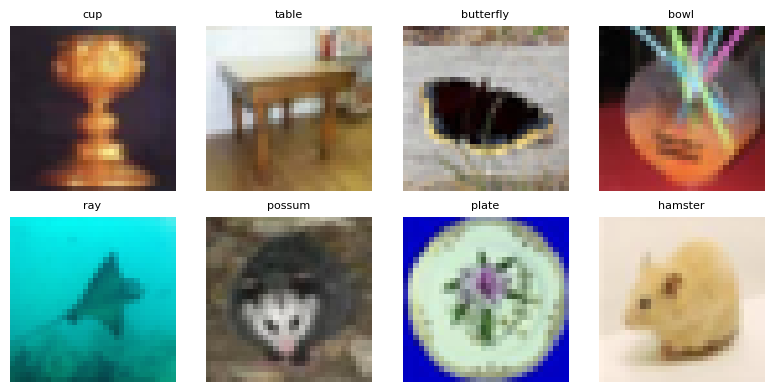

In [8]:
# Cell 8 — eyeball a few images with labels to confirm data + labels are sane
import matplotlib.pyplot as plt

xb, yb = next(iter(train_ds))            # one batch of [0,1] images
plt.figure(figsize=(8, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(xb[i].numpy())            # already [0,1], imshow-friendly
    plt.title(CLASS_NAMES[int(yb[i])], fontsize=8)
    plt.axis("off")
plt.tight_layout(); plt.show()

## 9 · Build the model

This uses the Keras functional API: each layer is called on the previous tensor to wire up a graph, and the resulting input and output tensors are passed to `Model`. It is the TensorFlow counterpart to writing an explicit `forward()` method. `include_top=False` removes ImageNet's 1000-way classifier and keeps the backbone, the convolutional stack that outputs a feature map (a small spatial grid of channels). `GlobalAveragePooling2D` collapses that grid by averaging each channel over its spatial positions into one vector per image. This is the standard alternative to flattening into a large dense layer, and uses far fewer parameters.

Placing the `Resizing` layer inside the model means the 32→224 upscale runs on the GPU, so the pipeline streams only 32×32 tensors. That costs the same compute as feeding 224×224 directly but a fraction of the memory bandwidth. `backbone(x, training=False)` holds BatchNorm to its frozen ImageNet running statistics, and keeps BatchNorm in inference mode through the later unfrozen stage as well. `model.summary()` shows a large non-trainable parameter count (the frozen backbone) above a small trainable count (the head).

In [9]:
# Cell 9 — model: in-graph resize + rescale, frozen-BN backbone, new softmax head
backbone = tf.keras.applications.MobileNetV3Small(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,            # drop ImageNet's 1000-way classifier; keep the feature extractor
    weights="imagenet",
    include_preprocessing=True,   # backbone normalizes internally, but expects [0,255] input
)
backbone.trainable = False        # frozen stage: freeze the whole backbone

inputs = tf.keras.Input(shape=(32, 32, 3))                 # raw [0,1] image from the pipeline
x = tf.keras.layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)   # 32x32 -> 224x224 on the GPU
x = tf.keras.layers.Rescaling(255.0)(x)                    # [0,1] -> [0,255] for the backbone
x = backbone(x, training=False)        # BN uses frozen ImageNet stats
x = tf.keras.layers.GlobalAveragePooling2D()(x)            # feature map -> one vector per image
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
print("Backbone layers:", len(backbone.layers))
model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Backbone layers: 157


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,112,532 (4.24 MB)

 Trainable params: 173,412 (677.39 KB)

 Non-trainable params: 939,120 (3.58 MB)

## 10 · Metrics, callbacks, and the evaluation suite

These are defined once so both stages reuse them. `SparseCategoricalCrossentropy` is multiclass cross-entropy for integer labels, equivalent to PyTorch's `CrossEntropyLoss` on class indices, except that the head here already applies softmax. The two Keras metrics are top-1 (ordinary accuracy) and top-5 (whether the true class is among the five highest-probability predictions), which is a useful second view at 100 classes where top-1 alone is a harsh measure.

`evaluate_stage` produces the saved results for a stage. It reads `y_true` by iterating the unshuffled test set directly, so predictions and labels stay aligned; computes top-1 and top-5, macro precision/recall/F1, weighted F1, balanced accuracy, and Cohen's κ; prints the full `classification_report`; and writes a set of result files to Drive under the `{LEVEL}_{stage}_` prefix: a `metrics.json` of the headline numbers, a per-class CSV, raw and row-normalized confusion-matrix CSVs, a compressed `preds.npz` (which lets any metric be recomputed later without retraining), and a confusion-matrix PNG. `plot_curves` additionally writes each stage's training history to CSV.

In [10]:
# Cell 10 — metrics, callbacks, and the extensive per-stage evaluation/plotting helpers
import os, json
import pandas as pd
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             precision_score, recall_score,
                             balanced_accuracy_score, cohen_kappa_score)

metrics = [
    tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
    tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_acc"),
]

def make_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy", mode="max", patience=5,
            restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_accuracy", mode="max", factor=0.5, patience=3, min_lr=1e-7),
    ]

def evaluate_stage(model, test_ds, class_names, tag, save_dir=SAVE_DIR):
    # headline loss / top-1 / top-5 straight from Keras
    loss, top1, top5 = model.evaluate(test_ds, verbose=0)

    # detailed metrics need explicit predictions; pull y_true from the (unshuffled)
    # dataset itself so predictions and labels are guaranteed aligned
    y_true = np.concatenate([y.numpy() for _, y in test_ds])
    probs  = model.predict(test_ds, verbose=0)
    y_pred = probs.argmax(axis=1)

    macro_p     = precision_score(y_true, y_pred, average="macro", zero_division=0)
    macro_r     = recall_score(y_true, y_pred, average="macro", zero_division=0)
    macro_f1    = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    bal_acc     = balanced_accuracy_score(y_true, y_pred)
    kappa       = cohen_kappa_score(y_true, y_pred)

    headline = {
        "level": LEVEL, "stage": tag, "num_classes": int(len(class_names)),
        "loss": float(loss), "top1": float(top1), "top5": float(top5),
        "macro_precision": float(macro_p), "macro_recall": float(macro_r),
        "macro_f1": float(macro_f1), "weighted_f1": float(weighted_f1),
        "balanced_accuracy": float(bal_acc), "cohen_kappa": float(kappa),
    }

    print(f"\n===== {LEVEL} / {tag} =====")
    print(f"top-1 {top1:.4f} | top-5 {top5:.4f} | macro-F1 {macro_f1:.4f} | "
          f"weighted-F1 {weighted_f1:.4f} | bal-acc {bal_acc:.4f} | kappa {kappa:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3,
                                zero_division=0))

    # ---- persist the DETAIL for this case (LEVEL x stage) ----
    os.makedirs(save_dir, exist_ok=True)
    prefix = f"{save_dir}/{LEVEL}_{tag}"

    # 1) all headline metrics as one tidy JSON
    with open(f"{prefix}_metrics.json", "w") as f:
        json.dump(headline, f, indent=2)

    # 2) per-class precision / recall / F1 / support table
    rep = classification_report(y_true, y_pred, target_names=class_names,
                                digits=3, output_dict=True, zero_division=0)
    pd.DataFrame(rep).T.to_csv(f"{prefix}_per_class.csv")

    # 3) confusion matrix: raw counts AND row-normalised (per-true-class recall view)
    cm = confusion_matrix(y_true, y_pred)
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(f"{prefix}_confusion.csv")
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    pd.DataFrame(cm_norm, index=class_names,
                 columns=class_names).to_csv(f"{prefix}_confusion_norm.csv")

    # 4) raw predictions: recompute ANY metric later without retraining
    np.savez_compressed(f"{prefix}_preds.npz", y_true=y_true, y_pred=y_pred, probs=probs)

    # ---- confusion-matrix heatmap: shown AND saved as PNG ----
    plt.figure(figsize=(8, 7) if len(class_names) <= 20 else (12, 10))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"Confusion matrix — {LEVEL} / {tag}")
    plt.xlabel("predicted"); plt.ylabel("true"); plt.colorbar(fraction=0.046)
    if len(class_names) <= 20:                      # annotate only when readable
        plt.xticks(range(len(class_names)), class_names, rotation=90, fontsize=7)
        plt.yticks(range(len(class_names)), class_names, fontsize=7)
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                if cm[i, j]:
                    plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=6)
    plt.tight_layout()
    plt.savefig(f"{prefix}_confusion.png", dpi=150, bbox_inches="tight")  # save BEFORE show
    plt.show()

    return headline

def plot_curves(history, tag, save_dir=SAVE_DIR):
    h = history.history
    safe = tag.lower().replace(" ", "_").replace("(", "").replace(")", "")
    # dump the raw history so curves can be redrawn without retraining
    pd.DataFrame(h).to_csv(f"{save_dir}/{LEVEL}_{safe}_history.csv", index_label="epoch")
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(h["loss"], label="train"); ax[0].plot(h["val_loss"], label="val")
    ax[0].set_title(f"{tag} — loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(h["accuracy"], label="train"); ax[1].plot(h["val_accuracy"], label="val")
    ax[1].set_title(f"{tag} — accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout()
    fig.savefig(f"{save_dir}/{LEVEL}_{safe}_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

results = {}

## 11 · Frozen stage — train the head

`model.fit` is the training loop: forward pass, loss, backward pass, optimizer step, and validation. Callbacks are hooks that run around it. `EarlyStopping` monitors `val_accuracy`, stops when it plateaus, and with `restore_best_weights=True` rolls back to the best epoch, so we keep the best model rather than the last. `ReduceLROnPlateau` halves the learning rate when validation stalls, which lets Adam settle into a finer minimum. The accuracy reached here is the frozen baseline that the unfrozen stage is measured against.

In [11]:
# Cell 11 — frozen stage: compile (head-only, LR 1e-3) and train
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_S1),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=metrics,
)

history1 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_S1, callbacks=make_callbacks(),
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 42ms/step - accuracy: 0.3994 - loss: 2.3143 - top5_acc: 0.7106 - val_accuracy: 0.5986 - val_loss: 1.4276 - val_top5_acc: 0.8802 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5380 - loss: 1.6444 - top5_acc: 0.8453 - val_accuracy: 0.6282 - val_loss: 1.2955 - val_top5_acc: 0.8980 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.5661 - loss: 1.5139 - top5_acc: 0.8662 - val_accuracy: 0.6430 - val_loss: 1.2389 - val_top5_acc: 0.9060 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.5838 - loss: 1.4478 - top5_acc: 0.8766 - val_accuracy: 0.6526 - val_loss: 1.2121 - val_top5_acc: 0.9120 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.5965 - loss: 1.3982 - top5_acc: 0.8826 - val_accuracy: 0.6622 - val_loss: 1.1861 - val_top5_acc: 0.9102 - learning_rate: 0.0010
Epoch 6/30
704/704 ━

## 12 · Evaluate and checkpoint the frozen model

We run the full evaluation suite here, before fine-tuning, because the unfrozen stage overwrites these weights. This writes the first of the notebook's two result sets (`{LEVEL}_frozen_*`) and saves the frozen model to its own `.keras` file, so this case stays reproducible after fine-tuning.


===== fine / frozen =====
top-1 0.6929 | top-5 0.9213 | macro-F1 0.6902 | weighted-F1 0.6902 | bal-acc 0.6929 | kappa 0.6898
               precision    recall  f1-score   support

        apple      0.881     0.890     0.886       100
aquarium_fish      0.776     0.830     0.802       100
         baby      0.583     0.600     0.591       100
         bear      0.571     0.480     0.522       100
       beaver      0.602     0.560     0.580       100
          bed      0.691     0.670     0.680       100
          bee      0.641     0.750     0.691       100
       beetle      0.784     0.690     0.734       100
      bicycle      0.798     0.750     0.773       100
       bottle      0.898     0.790     0.840       100
         bowl      0.630     0.580     0.604       100
          boy      0.412     0.350     0.378       100
       bridge      0.753     0.700     0.725       100
          bus      0.649     0.610     0.629       100
    butterfly      0.722     0.650     0.684    

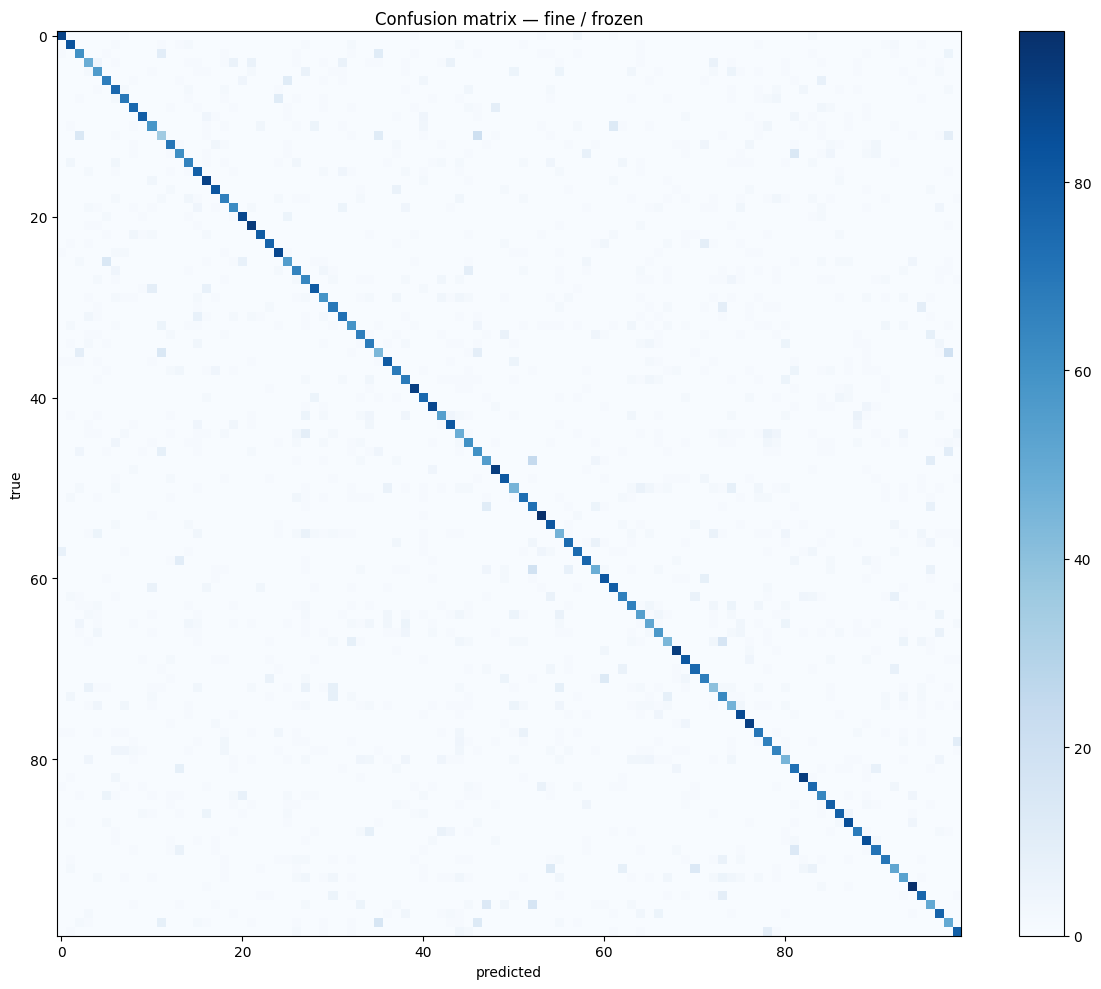

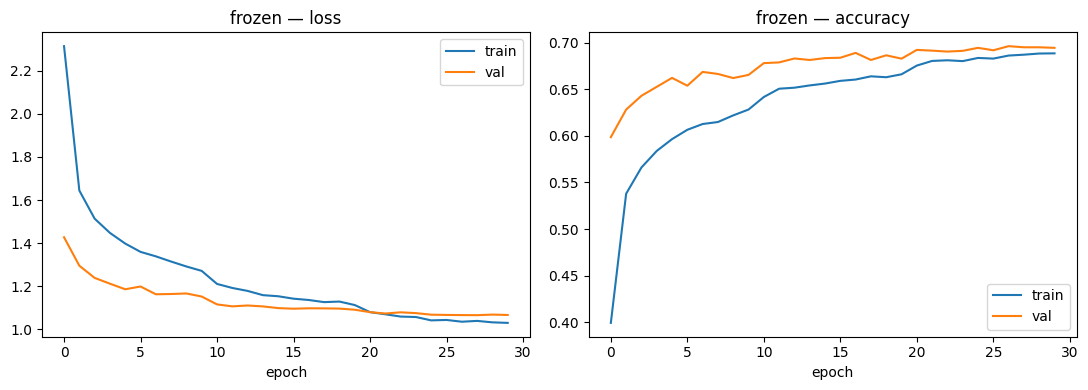

Saved frozen model + results to /content/drive/MyDrive/cifar100_mnv3/fine


In [12]:
# Cell 12 — full evaluation of the frozen model, its curves, and a frozen checkpoint
results["frozen"] = evaluate_stage(model, test_ds, CLASS_NAMES, "frozen")
plot_curves(history1, "frozen")
model.save(f"{SAVE_DIR}/model_{LEVEL}_frozen.keras")   # frozen case, fully reproducible
print("Saved frozen model + results to", SAVE_DIR)

## 13 · Unfrozen stage — fine-tune the top of the backbone

Two Keras behaviors matter here. The first is the container rule: a layer trains only if both the layer and its enclosing model are trainable. So we set `backbone.trainable = True` first and then re-freeze layers selectively; otherwise the per-layer flags are silently overridden. We keep all `BatchNormalization` layers frozen regardless of the cutoff, which together with the `training=False` already pinned in the graph keeps BatchNorm fully inert: neither its running statistics nor its gamma and beta parameters move.

The second is that the model must be recompiled after changing trainable flags. Without recompiling, Keras keeps the previous list of trainable variables and trains only the head, with no error raised. The jump in trainable-parameter count after recompiling confirms the change took effect. The learning rate is 100 times smaller than in the frozen stage, so the pretrained weights are adjusted rather than rewritten.

In [13]:
# Cell 13 — unfrozen stage: unfreeze top ~30% of backbone (BN stays frozen), retrain at LR 1e-5
backbone.trainable = True                       # unlock the container first
cutoff = int(len(backbone.layers) * (1 - UNFREEZE_FRAC))
for i, layer in enumerate(backbone.layers):
    # freeze everything below the cutoff, and freeze ALL BatchNorm layers regardless
    if i < cutoff or isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

n_trainable = sum(1 for l in backbone.layers if l.trainable)
print(f"Unfrozen backbone layers: {n_trainable} of {len(backbone.layers)} (cutoff idx {cutoff})")

# recompile is REQUIRED after changing trainable flags; fresh Adam at the tiny LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_S2),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=metrics,
)
print("Trainable params now:", f"{sum(int(tf.size(w)) for w in model.trainable_weights):,}")

history2 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_S2, callbacks=make_callbacks(),
)

Unfrozen backbone layers: 38 of 157 (cutoff idx 109)
Trainable params now: 902,412
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 50ms/step - accuracy: 0.7001 - loss: 0.9795 - top5_acc: 0.9363 - val_accuracy: 0.7130 - val_loss: 0.9857 - val_top5_acc: 0.9328 - learning_rate: 1.0000e-05
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.7145 - loss: 0.9383 - top5_acc: 0.9445 - val_accuracy: 0.7190 - val_loss: 0.9630 - val_top5_acc: 0.9356 - learning_rate: 1.0000e-05
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.7192 - loss: 0.9152 - top5_acc: 0.9467 - val_accuracy: 0.7226 - val_loss: 0.9483 - val_top5_acc: 0.9378 - learning_rate: 1.0000e-05
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.7251 - loss: 0.8854 - top5_acc: 0.9499 - val_accuracy: 0.7232 - val_loss: 0.9398 - val_top5_acc: 0.9402 - learning_rate: 1.0000e-05
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.7306 - loss: 0.8775 - top5_acc: 0.9505 - val_accu

## 14 · Evaluate and checkpoint the unfrozen model

The same suite runs on the fine-tuned model, writing the second result set (`{LEVEL}_unfrozen_*`) and the unfrozen checkpoint. Comparing this confusion matrix against the frozen one shows which classes fine-tuning improved, which is often more informative than the change in the headline metric alone.


===== fine / unfrozen =====
top-1 0.7461 | top-5 0.9482 | macro-F1 0.7445 | weighted-F1 0.7445 | bal-acc 0.7461 | kappa 0.7435
               precision    recall  f1-score   support

        apple      0.910     0.910     0.910       100
aquarium_fish      0.824     0.890     0.856       100
         baby      0.660     0.660     0.660       100
         bear      0.643     0.540     0.587       100
       beaver      0.610     0.610     0.610       100
          bed      0.763     0.740     0.751       100
          bee      0.770     0.870     0.817       100
       beetle      0.846     0.770     0.806       100
      bicycle      0.895     0.850     0.872       100
       bottle      0.915     0.860     0.887       100
         bowl      0.670     0.590     0.628       100
          boy      0.489     0.430     0.457       100
       bridge      0.798     0.750     0.773       100
          bus      0.744     0.670     0.705       100
    butterfly      0.844     0.760     0.800  

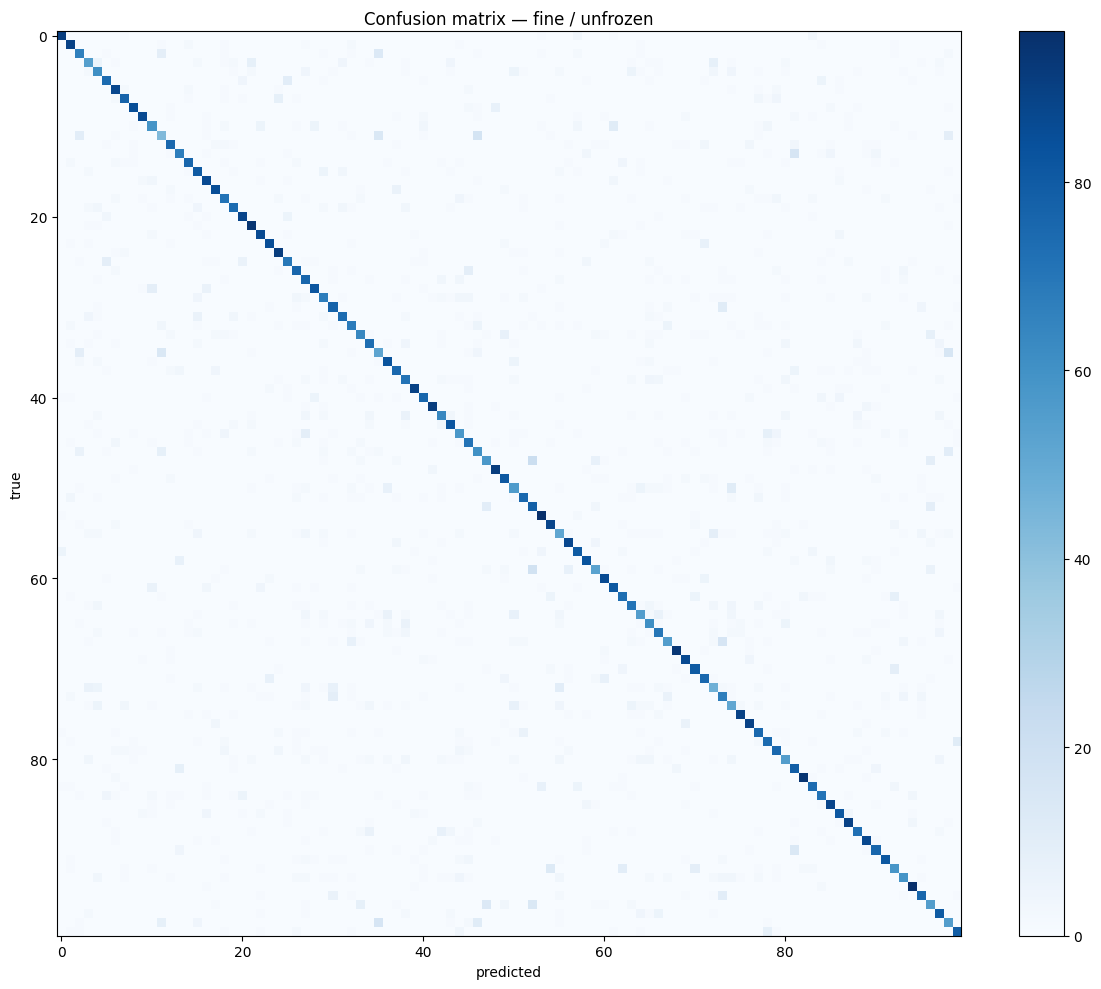

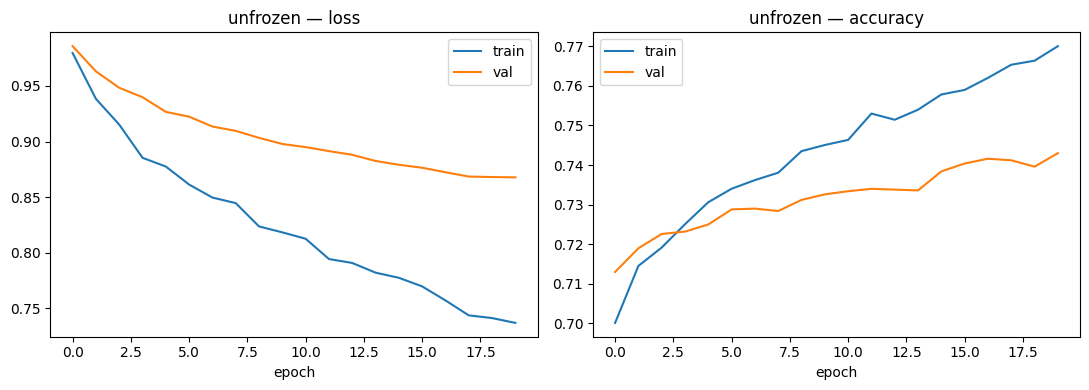

Saved unfrozen model + results to /content/drive/MyDrive/cifar100_mnv3/fine


In [14]:
# Cell 14 — full evaluation of the unfrozen model, its curves, and an unfrozen checkpoint
results["unfrozen"] = evaluate_stage(model, test_ds, CLASS_NAMES, "unfrozen")
plot_curves(history2, "unfrozen")
model.save(f"{SAVE_DIR}/model_{LEVEL}_unfrozen.keras")   # unfrozen case, fully reproducible
print("Saved unfrozen model + results to", SAVE_DIR)

## 15 · Frozen vs. unfrozen comparison

A single table across the full metric set, with a `frozen` row, an `unfrozen` row, and a `delta` row giving the improvement from fine-tuning. The table is saved to Drive as `summary_{LEVEL}.csv`.

In [15]:
# Cell 15 — headline comparison across the full metric set: what fine-tuning bought
summary = pd.DataFrame(results.values()).set_index("stage")
cols = ["top1", "top5", "macro_precision", "macro_recall",
        "macro_f1", "weighted_f1", "balanced_accuracy", "cohen_kappa"]
summary = summary[cols].round(4)
summary.loc["delta"] = (summary.loc["unfrozen"] - summary.loc["frozen"]).round(4)
print(summary)
summary.to_csv(f"{SAVE_DIR}/summary_{LEVEL}.csv")

            top1    top5  macro_precision  macro_recall  macro_f1  \
stage                                                               
frozen    0.6929  0.9213           0.6922        0.6929    0.6902   
unfrozen  0.7461  0.9482           0.7461        0.7461    0.7445   
delta     0.0532  0.0269           0.0539        0.0532    0.0543   

          weighted_f1  balanced_accuracy  cohen_kappa  
stage                                                  
frozen         0.6902             0.6929       0.6898  
unfrozen       0.7445             0.7461       0.7435  
delta          0.0543             0.0532       0.0537  


## 16 · Persist the training histories

The two `.keras` model files are already saved (cells 12 and 14). Here we pickle both stages' training histories together so any curve can be redrawn later without retraining. Everything is written to the per-`LEVEL` folder.

In [16]:
# Cell 16 — persist both stages' histories to Drive (Colab wipes local disk on reset)
import pickle

with open(f"{SAVE_DIR}/history_{LEVEL}.pkl", "wb") as f:
    pickle.dump({"frozen": history1.history, "unfrozen": history2.history}, f)

print("Saved histories to", SAVE_DIR)
print("Artifacts for this notebook:")
for fn in sorted(os.listdir(SAVE_DIR)):
    print("  ", fn)

Saved histories to /content/drive/MyDrive/cifar100_mnv3/fine
Artifacts for this notebook:
   fine_frozen_confusion.csv
   fine_frozen_confusion.png
   fine_frozen_confusion_norm.csv
   fine_frozen_curves.png
   fine_frozen_history.csv
   fine_frozen_metrics.json
   fine_frozen_per_class.csv
   fine_frozen_preds.npz
   fine_unfrozen_confusion.csv
   fine_unfrozen_confusion.png
   fine_unfrozen_confusion_norm.csv
   fine_unfrozen_curves.png
   fine_unfrozen_history.csv
   fine_unfrozen_metrics.json
   fine_unfrozen_per_class.csv
   fine_unfrozen_preds.npz
   history_fine.pkl
   model_fine_frozen.keras
   model_fine_unfrozen.keras
   summary_fine.csv


## Runtime, limits, and what to watch

At 224px with batch 64 on a T4, the first epoch of each stage takes around 50 seconds, because TensorFlow compiles the graph and cuDNN autotunes its kernels on that pass; subsequent epochs settle to roughly 12 to 20 seconds each. With `EarlyStopping`, each stage typically finishes within 15 to 30 epochs, so each stage takes a few minutes and the full frozen-then-unfrozen run is on the order of 10 to 20 minutes, plus a one-time dataset download and decode of a minute or two. (These figures come from the coarse notebook's run on a T4; the fine head adds only 80 output units, which has no meaningful effect on epoch time.) Free Colab disconnects after about 90 minutes idle and caps sessions near 12 hours, so the tab should stay active. Because models and per-stage results are written to Drive as each stage completes, a disconnect after a stage finishes does not lose that stage.

Two practical adjustments. If training raises `ResourceExhaustedError` (out of GPU memory), lower `BATCH` to 32. For faster iteration while debugging, set `IMG_SIZE = 96`: the backbone's compute scales with input area, so this is several times quicker, after which it should go back to 224 for the real run.

This notebook covers the fine half of the four result sets (`fine_frozen` and `fine_unfrozen`); the coarse notebook produces the other half. Three points to check while running: after the load cell, confirm the columns are `img / fine_label / coarse_label`; after the frozen training cell, note the frozen `val_accuracy` as the baseline; and in the unfrozen cell, the trainable-parameter count must jump when the backbone is partially unfrozen — if it does not, the recompile did not take effect.